In [ ]:
import numpy as np
import pandas as pd
import os
from PIL import Image
from skimage.transform import resize
from tqdm import tqdm
import pydicom
import matplotlib.pyplot as plt

In [ ]:
BASE_PATH = "/home/orrin/aps360/pediatric-cxr-model/"
DATA_BASE_PATH = os.path.join(BASE_PATH, "data_raw/")
SAVE_BASE_PATH = os.path.join(BASE_PATH, "data_cleaned/")
SAVE_PATH_IMAGES = os.path.join(SAVE_BASE_PATH, "images/")
SAVE_PATH_ANNOTATIONS = os.path.join(SAVE_BASE_PATH, "annotations/")

DESIRED_IMG_SIZE = (130,100)

if not os.path.exists(SAVE_BASE_PATH):
    os.makedirs(SAVE_BASE_PATH)
if not os.path.exists(SAVE_PATH_IMAGES):
    os.makedirs(SAVE_PATH_IMAGES)
if not os.path.exists(SAVE_PATH_ANNOTATIONS):
    os.makedirs(SAVE_PATH_ANNOTATIONS)

In [ ]:
# define standard pandas df column names
column_names = [
    "filename",
    "no finding",
    "bronchitis",
    "broncho-pnuemonia",
    "pneumonia",
    "bronchiolitis",
    "heart disease",
    "atelectasis",
    "consolidation",
    "infiltration",
    "pneumothorax",
    "effusion",
    "other",
    "has bbox",
    "min_x",
    "min_y",
    "width",
    "height",
]

# helper function to add to df
def add_to_df(df, filename, label, min_x=None, min_y=None, width=None, height=None):
    # make sure label in valid label names
    if label not in column_names:
        raise ValueError(f"Label {label} not in column names")
    # make sure either all bbox values are None or all bbox values are not None
    if min_x is not None and (min_y is None or width is None or height is None) or \
        min_y is not None and (min_x is None or width is None or height is None) or \
        width is not None and (min_x is None or min_y is None or height is None) or \
        height is not None and (min_x is None or min_y is None or width is None):
        raise ValueError("Either all bbox values must be None or all bbox values must be not None")
        
    row = {
        "filename": filename,
        "no finding": 1 if "no finding" == label else 0,
        "bronchitis": 1 if "bronchitis" == label else 0,
        "broncho-pnuemonia": 1 if "broncho-pnuemonia" == label else 0,
        "pneumonia": 1 if "pneumonia" == label else 0,
        "bronchiolitis": 1 if "bronchiolitis" == label else 0,
        "heart disease": 1 if "heart disease" == label else 0,
        "atelectasis": 1 if "atelectasis" == label else 0,
        "consolidation": 1 if "consolidation" == label else 0,
        "infiltration": 1 if "infiltration" == label else 0,
        "pneumothorax": 1 if "pneumothorax" == label else 0,
        "effusion": 1 if "effusion" == label else 0,
        "other": 1 if "other" == label else 0,
        "has bbox": 1 if min_x is not None else 0,
        "min_x": min_x,
        "min_y": min_y,
        "width": width,
        "height": height,
    }
    df.loc[len(df)] = row

# helper function to visualize a single image and its bounding box
def visualize_image_with_bbox(df, row_index):
    # get row and image
    row = df.iloc[row_index]
    img_path = os.path.join(SAVE_PATH_IMAGES, row["filename"])
    img = np.array(Image.open(img_path).convert("L"))
    # get label from one-hot encoding row
    label = None
    for col in column_names[1:13]:  # skip filename and bbox columns
        if row[col] == 1:
            label = col
            break
    # plot
    plt.imshow(img, cmap="gray")
    if row["has bbox"] == 1:
        x_min = row["min_x"]
        y_min = row["min_y"]
        width = row["width"]
        height = row["height"]
        rect = plt.Rectangle((x_min, y_min), width, height, edgecolor="red", facecolor="none")
        plt.gca().add_patch(rect)
    plt.title(f"{row["filename"]} - {label}")
    plt.axis("off")
    plt.show()

  0%|          | 1/1583 [00:00<03:22,  7.80it/s]

100%|██████████| 4273/4273 [02:56<00:00, 24.18it/s]


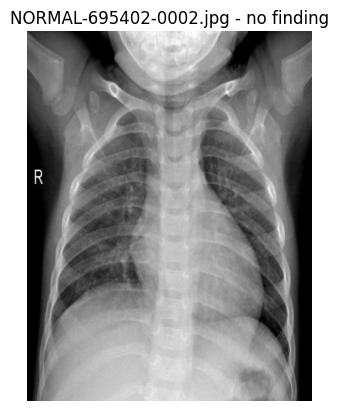

In [4]:
## Kermany Dataset
df_kermany = pd.DataFrame(columns=column_names)

# Create Label CSV for Kermany Dataset
DATA_PATH = os.path.join(DATA_BASE_PATH, "kermany")
FOLDERS = ['NORMAL', 'PNEUMONIA']

for folder in FOLDERS:
    folder_path = os.path.join(DATA_PATH, folder)
    files = os.listdir(folder_path)

    # get label
    if folder == 'NORMAL':
        label = 'no finding'
    else:
        label = 'pneumonia'

    for file in tqdm(files):
        # resize image
        img_path = os.path.join(folder_path, file)
        img = np.array(Image.open(img_path).convert("L"))  # convert to grayscale
        img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
        img_resized = (img_resized * 255).astype(np.uint8)  # convert back to uint8

        # save image
        save_extension = ".jpg"
        if not file.endswith(save_extension):
            save_file = os.path.splitext(file)[0] + save_extension
        save_path = os.path.join(SAVE_PATH_IMAGES, save_file)
        Image.fromarray(img_resized).save(save_path)

        # add to df
        add_to_df(
            df_kermany,
            filename=save_file,
            label=label,
        )

# create dataframe and save to csv
df_kermany.to_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "kermany_annotations.csv"), index=False)
# visualize first image
visualize_image_with_bbox(df_kermany, 0)

100%|██████████| 210/210 [00:04<00:00, 42.14it/s]


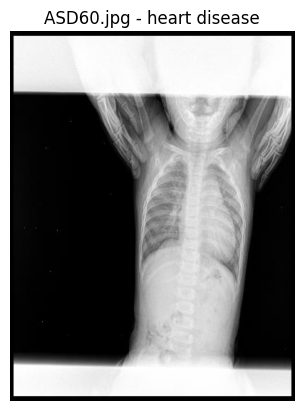

In [5]:
## Congenital Heart Disease Dataset
df_heart = pd.DataFrame(columns=column_names)

# Create Label CSV for Congenital Heart Disease Dataset
DATA_PATH = os.path.join(DATA_BASE_PATH, "congenital-heart-disease")
FOLDERS = ['ASD', 'Normal', 'PDA', 'VSD']

for folder in FOLDERS:
    folder_path = os.path.join(DATA_PATH, folder)
    files = os.listdir(folder_path)

    # get label
    if folder == 'Normal':
        label = 'no finding'
    else:
        label = 'heart disease'

    for file in tqdm(files):
        # resize image
        img_path = os.path.join(folder_path, file)
        img = np.array(Image.open(img_path).convert("L"))  # convert to grayscale
        img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
        img_resized = (img_resized * 255).astype(np.uint8)  # convert back to uint8

        # save image
        save_extension = ".jpg"
        if not file.endswith(save_extension):
            save_file = os.path.splitext(file)[0] + save_extension
        else:
            save_file = file
        save_path = os.path.join(SAVE_PATH_IMAGES, save_file)
        Image.fromarray(img_resized).save(save_path)

        # add to df
        add_to_df(
            df_heart,
            filename=save_file,
            label=label,
        )

# create dataframe and save to csv
df_heart.to_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "congenital_heart_disease_annotations.csv"), index=False)
# visualize first image
visualize_image_with_bbox(df_heart, 0)

In [6]:
# get NIH dataset
nih_entries = pd.read_csv(os.path.join(DATA_BASE_PATH, 'nih', 'Data_Entry_2017.csv'))

# get all pediatric patients
mask = nih_entries['Patient Age'] < 19
nih_peds = nih_entries[mask]

# only keep first label for each image
for idx, row in tqdm(nih_peds.iterrows(), total=nih_peds.shape[0]):
    label = row['Finding Labels'].split('|')[0]
    nih_peds.at[idx, 'Finding Labels'] = label
print(nih_peds.head())

100%|██████████| 5941/5941 [00:00<00:00, 12194.68it/s]

           Image Index Finding Labels  Follow-up #  Patient ID  Patient Age  \
2031  00000522_000.png    Atelectasis            0         522           17   
2032  00000522_001.png     No Finding            1         522           18   
2146  00000564_000.png     No Finding            0         564           17   
2147  00000565_000.png     No Finding            0         565           18   
2652  00000702_000.png     No Finding            0         702           17   

     Patient Gender View Position  OriginalImage[Width  Height]  \
2031              M            AP                 2048     2500   
2032              M            AP                 2500     2048   
2146              M            PA                 2048     2500   
2147              F            PA                 2048     2500   
2652              F            PA                 2048     2500   

      OriginalImagePixelSpacing[x     y]  Unnamed: 11  
2031                        0.171  0.171          NaN  
2032      

In [7]:
# download pediatric images of interest

# folders containing range of image ids
folders = [
    'images_001',
    'images_002',
    'images_003',
    'images_004',
    'images_005',
    'images_006',
    'images_007',
    'images_008',
    'images_009',
    'images_010',
    'images_011',
    'images_012',
]

save_dir = os.path.join(DATA_BASE_PATH, "nih", 'images')
folder_i = 0

for idx, row in tqdm(nih_peds.iterrows(), total=nih_peds.shape[0]):
    fname = row['Image Index']
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        continue

    success = False
    while not success and folder_i < len(folders):
        # use kaggle api to download image
        folder = folders[folder_i]
        cmd = f"kaggle datasets download -d nih-chest-xrays/data --file {folder}/images/{fname} -p {save_dir}"
        val = os.system(cmd)
        success = True if val == 0 else False
        if not success:
            folder_i += 1

100%|██████████| 5941/5941 [00:00<00:00, 14056.19it/s]


 35%|███▍      | 2070/5941 [02:30<04:08, 15.56it/s]

Failed to Process /home/orrin/aps360/pediatric-cxr-model/data_raw/nih/images/00029802_000.png


100%|██████████| 5941/5941 [07:01<00:00, 14.10it/s]


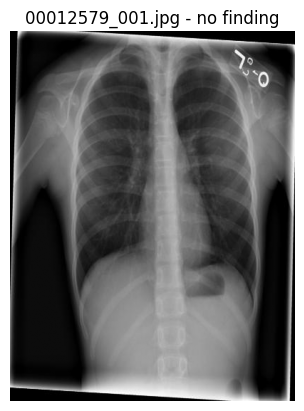

In [42]:
# process nih dataset
df_nih = pd.DataFrame(columns=column_names)

# Create Label CSV for Congenital Heart Disease Dataset
DATA_PATH = os.path.join(DATA_BASE_PATH, "nih")
IMAGE_PATH = os.path.join(DATA_PATH, "images")
files = os.listdir(IMAGE_PATH)

# load bbox data
bbox_data = pd.read_csv(os.path.join(DATA_PATH, "BBox_List_2017.csv"))

for file in tqdm(files):
    # get label
    row = nih_peds[nih_peds['Image Index'] == file]
    finding_label = row['Finding Labels'].values[0]
    if finding_label == 'No Finding':
        label = 'no finding'
    elif finding_label == 'Infiltration':
        label = 'infiltration'
    elif finding_label == 'Atelactasis':
        label = 'atelectasis'
    elif finding_label == 'Consolidation':
        label = 'consolidation'
    elif finding_label == 'Effusion':
        label = 'effusion'
    # elif finding_label == 'Pneumothorax':
    #     label = 'pneumothorax'
    elif finding_label == 'Cardiomegaly':
        label = 'heart disease'
    elif finding_label == 'Pneumonia':
        label = 'pneumonia'
    else:
        label = 'other'

    # resize image
    img_path = os.path.join(IMAGE_PATH, file)
    try:
        img = np.array(Image.open(img_path).convert("L"))  # convert to grayscale
    except:
        print(f"Failed to Process {img_path}")
        continue
    img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
    img_resized = (img_resized * 255).astype(np.uint8)  # convert back to uint8
    scaled_ratio_x = img_resized.shape[1] / img.shape[1]
    scaled_ratio_y = img_resized.shape[0] / img.shape[0]

    # save image
    save_extension = ".jpg"
    if not file.endswith(save_extension):
        save_file = os.path.splitext(file)[0] + save_extension
    save_path = os.path.join(SAVE_PATH_IMAGES, save_file)
    Image.fromarray(img_resized).save(save_path)

    # get bbox if exists
    mask = bbox_data['Image Index'] == file
    bbox_row = bbox_data[mask]
    if bbox_row.shape[0] > 0:
        min_x = bbox_row['Bbox [x'].values[0] * scaled_ratio_x
        min_y = bbox_row['y'].values[0] * scaled_ratio_y
        width = bbox_row['w'].values[0] * scaled_ratio_x
        height = bbox_row['h]'].values[0] * scaled_ratio_y
    else:
        min_x = None
        min_y = None
        width = None
        height = None

    # add to df
    add_to_df(
        df_nih,
        filename=save_file,
        label=label,
        min_x=min_x,
        min_y=min_y,
        width=width,
        height=height,
    )

# create dataframe and save to csv
df_nih.to_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "nih_annotations.csv"), index=False)
# visualize first image
visualize_image_with_bbox(df_nih, 0)

 35%|███▌      | 2742/7728 [43:57<16:32,  5.02it/s]     

Failed to Process /mnt/e/APS360_data/data/data/train/99905540dca6c8ece8e07ace8362b679.dicom


 36%|███▋      | 2814/7728 [44:20<33:31,  2.44it/s]  

Failed to Process /mnt/e/APS360_data/data/data/train/d22b70c6029843ebff15c7e0d0c4b259.dicom


100%|██████████| 1397/1397 [06:52<00:00,  3.39it/s]


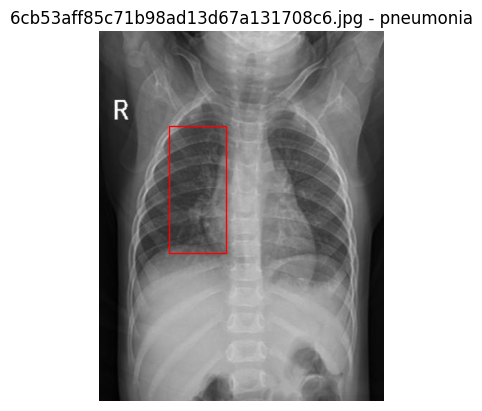

In [ ]:
# process pedcxr
df_pedcxr = pd.DataFrame(columns=column_names)

# Create Label CSV for Congenital Heart Disease Dataset
DATA_PATH = os.path.join(DATA_BASE_PATH, "pedcxr")
DATA_PATH = '/mnt/e/APS360_data/data/data'
PATH_SUFFIXES = ['train', 'test']

for suffix in PATH_SUFFIXES:
    df_annot = pd.read_csv(os.path.join(DATA_PATH, f"annotations_{suffix}.csv"))
    df_labels = pd.read_csv(os.path.join(DATA_PATH, f"image_labels_{suffix}.csv"))
    IMAGE_PATH = os.path.join(DATA_PATH, suffix)

    for idx, row in tqdm(df_labels.iterrows(), total=df_labels.shape[0]):
        # get label from one hot encoding columns
        label = row[2:].idxmax()  # get column name of max value

        if label == 'No finding':
            label = 'no finding'
        elif label == 'Bronchitis':
            label = 'bronchitis'
        elif label == 'Brocho-pneumonia':
            label = 'broncho-pnuemonia'
        elif label == 'Bronchiolitis':
            label = 'bronchiolitis'
        elif label == 'Pneumonia':
            label = 'pneumonia'
        else:
            label = 'other'

        # resize image
        fname = f"{row['image_id']}.dicom"
        img_path = os.path.join(IMAGE_PATH, fname)
        try:
            # load
            img = np.array(pydicom.dcmread(img_path).pixel_array)
            # normalize
            max_ = img.max()
            min_ = img.min()
            img = (img - min_) / (max_ - min_)
            # invert so background is black and skeleton is white
            # this is to be consistent with other datasets
            img = np.abs(img - 1)
        except:
            print(f"Failed to Process {img_path}")
            continue
        img_resized = resize(img, DESIRED_IMG_SIZE, anti_aliasing=True)
        img_resized = (img_resized * 255).astype(np.uint8)  # convert back to uint8
        scaled_ratio_x = img_resized.shape[1] / img.shape[1]
        scaled_ratio_y = img_resized.shape[0] / img.shape[0]


        # save image
        save_extension = ".jpg"
        if not fname.endswith(save_extension):
            save_file = os.path.splitext(fname)[0] + save_extension
        else:
            save_file = fname
        save_path = os.path.join(SAVE_PATH_IMAGES, save_file)
        Image.fromarray(img_resized).save(save_path)

        # get bbox if exists
        mask = df_annot['image_id'] == row['image_id']
        bbox_row = df_annot[mask]

        ### plot original image with bbox for debugging
        # plt.imshow(img, cmap="gray")
        # x_min = bbox_row['x_min'].values[0]
        # y_min = bbox_row['y_min'].values[0]
        # x_max = bbox_row['x_max'].values[0]
        # y_max = bbox_row['y_max'].values[0]
        # width = x_max - x_min
        # height = y_max - y_min
        # rect = plt.Rectangle((x_min, y_min), width, height, edgecolor="red", facecolor="none")
        # plt.gca().add_patch(rect)
        # print(x_min, x_max, y_min, y_max)
        # plt.title(f"{fname} - {label}")
        # plt.show()

        if bbox_row.shape[0] > 0 and label != 'no finding':
            x_min = bbox_row['x_min'].values[0] * scaled_ratio_x
            x_max = bbox_row['x_max'].values[0] * scaled_ratio_x
            y_min = bbox_row['y_min'].values[0] * scaled_ratio_y
            y_max = bbox_row['y_max'].values[0] * scaled_ratio_y
            width = x_max - x_min
            height = y_max - y_min
        else:
            x_min = None
            y_min = None
            width = None
            height = None

        # add to df
        add_to_df(
            df_pedcxr,
            filename=save_file,
            label=label,
            min_x=x_min,
            min_y=y_min,
            width=width,
            height=height,
        )

# create dataframe and save to csv
df_pedcxr.to_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "pedcxr_annotations.csv"), index=False)
# visualize first image
visualize_image_with_bbox(df_pedcxr, 0)

In [43]:
# Save all labels into a master csv
df_kermany = pd.read_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "kermany_annotations.csv"))
df_heart = pd.read_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "congenital_heart_disease_annotations.csv"))
df_nih = pd.read_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "nih_annotations.csv"))
df_pedcxr = pd.read_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "pedcxr_annotations.csv"))
df_master = pd.concat([df_kermany, df_heart, df_nih, df_pedcxr], ignore_index=True)
df_master.to_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "master_annotations.csv"), index=False)

In [44]:
# version of master annotations without one-hot encoding
def remove_one_hotness(df):
    # get label
    df['label'] = df.apply(lambda row: row[row == 1].index[0] if 1 in row.values else 'no finding', axis=1)
    df = df[['filename', 'label', 'has bbox', 'min_x', 'min_y', 'width', 'height']]
    return df

df_master_alternate = remove_one_hotness(df_master)
df_master_alternate.to_csv(os.path.join(SAVE_PATH_ANNOTATIONS, "master_annotations_alternate.csv"), index=False)

In [46]:
# get some stats about data
print("Total number of data points:", len(df_master))
print("Total number with bbox:", sum(df_master['has bbox']))
print("Label distribution:")
print(df_master['label'].value_counts())

Total number of data points: 21747
Total number with bbox: 9162
Label distribution:
label
no finding           11382
pneumonia             4722
other                 1477
bronchitis            1016
heart disease          765
infiltration           756
broncho-pnuemonia      577
bronchiolitis          519
effusion               306
consolidation          227
Name: count, dtype: int64
